### K-Means 

In [1]:
# Fake Data
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, Y = make_blobs(
    n_samples=200,
    n_features=2,
    centers=3,
    cluster_std=1,
    shuffle=True,
    random_state=7
)

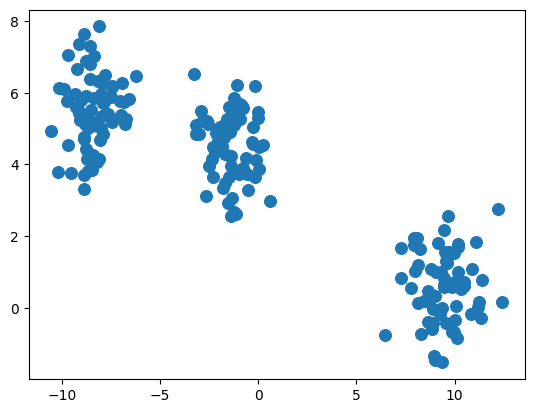

In [2]:
plt.scatter(X[:, 0], X[:,1], marker='o', s=70)
plt.show()

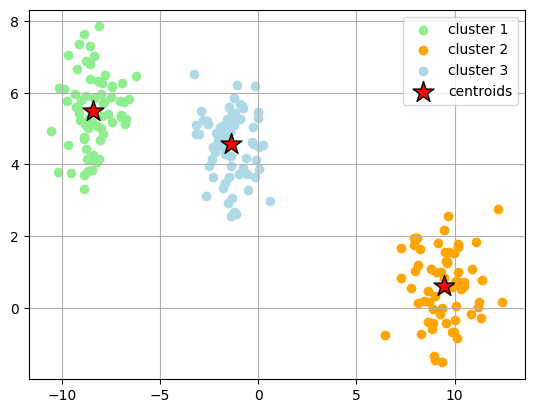

In [6]:
#K-Means Fit
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, max_iter=500)
y_km = km.fit_predict(X)

#plot the 3 clusters
plt.scatter(X[y_km == 0, 0], X[y_km == 0, 1], c='lightgreen', label='cluster 1')
plt.scatter(X[y_km == 1, 0], X[y_km == 1, 1], c='orange', label='cluster 2')
plt.scatter(X[y_km == 2, 0], X[y_km == 2, 1], c='lightblue', label='cluster 3')

#plot the centroids
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:,1], s=250, marker='*', c='red', edgecolor='black', label='centroids')
plt.legend(scatterpoints=1)
plt.grid()


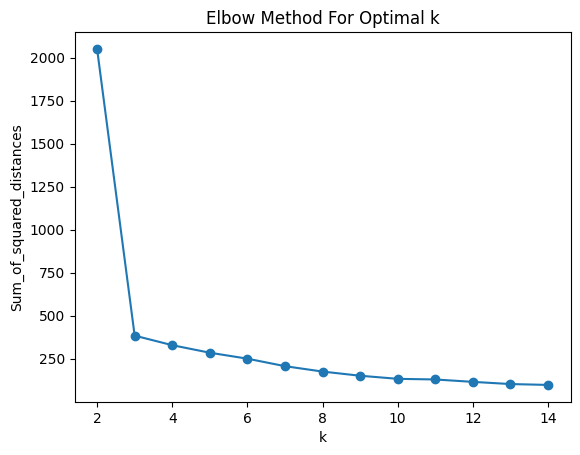

In [9]:
#Elbow Method
Sum_of_squared_distances = []
K = range(2,15)
for k in K:
    km = KMeans(n_clusters=k, init='random', n_init=10, max_iter=500, random_state=0)
    km = km.fit(X)

    Sum_of_squared_distances.append(km.inertia_)

# Plot Results
plt.plot(K, Sum_of_squared_distances, marker='o')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()


In [10]:
#Silhouette Analysis
from sklearn.metrics import silhouette_score
for n_clusters in range(2,10):
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is: {:4f}".format(silhouette_avg))

For n_clusters = 2 The average silhouette_score is: 0.748643
For n_clusters = 3 The average silhouette_score is: 0.785358
For n_clusters = 4 The average silhouette_score is: 0.641820
For n_clusters = 5 The average silhouette_score is: 0.461010
For n_clusters = 6 The average silhouette_score is: 0.477107
For n_clusters = 7 The average silhouette_score is: 0.325233
For n_clusters = 8 The average silhouette_score is: 0.478205
For n_clusters = 9 The average silhouette_score is: 0.361148


### Case Study
#### Clusering Travel Agency Booking Data


In [13]:
#Downloading The Data
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/clustering/travel.csv',
parse_dates = ['date_time','srch_ci','srch_co'])
df.head()

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,...,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
0,2014-11-03 16:02:00,24,2,77,871,36643,456.1151,792280,0,1,...,0,1,8286,1,0,1,0,63,1258,68
1,2013-03-13 19:25:00,11,3,205,135,38749,232.4737,961995,0,0,...,0,1,1842,3,0,1,2,198,786,37
2,2014-10-13 13:20:00,2,3,66,314,48562,4468.2720,495669,0,1,...,0,1,8746,1,0,1,6,105,29,22
3,2013-11-05 10:40:00,11,3,205,411,52752,171.6021,106611,0,0,...,0,1,6210,3,1,1,2,198,1234,42
4,2014-06-10 13:34:00,2,3,66,174,50644,NaN,596177,0,0,...,1,1,12812,5,0,1,2,50,368,83


In [14]:
df.to_csv('../data/clustering/travel.csv')

In [15]:
# Get some base information on our dataset
print ("Rows:   " , df.shape[0])
print ("Columns: " , df.shape[1])

Rows:    100000
Columns:  24


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   date_time                  100000 non-null  datetime64[us]
 1   site_name                  100000 non-null  int64         
 2   posa_continent             100000 non-null  int64         
 3   user_location_country      100000 non-null  int64         
 4   user_location_region       100000 non-null  int64         
 5   user_location_city         100000 non-null  int64         
 6   orig_destination_distance  63915 non-null   float64       
 7   user_id                    100000 non-null  int64         
 8   is_mobile                  100000 non-null  int64         
 9   is_package                 100000 non-null  int64         
 10  channel                    100000 non-null  int64         
 11  srch_ci                    99878 non-null   datetime64[us]
 12  